# APM1220 — Formative Assessment 4
## https://github.com/ABADMARIA/APM1220/tree/main/FAs/FA4

This notebook contains solutions to all four problems: Hotelling's $T^2$ test, simultaneous/Bonferroni confidence regions for grizzly bear measurements, the Peruvian hair mineral analysis, and the lumber strength data.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['axes.grid'] = True

def plot_confidence_ellipse(mean, cov, crit_val, n, ax, label=None, color='C0', **kwargs):
    """Plot a confidence ellipse {mu : n*(mean-mu)'cov^-1(mean-mu) <= crit_val}."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * np.sqrt(eigvals * crit_val / n)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  facecolor='none', edgecolor=color, lw=2, label=label, **kwargs)
    ax.add_patch(ell)
    ax.plot(*mean, marker='+', color=color, ms=12, mew=2)
    return ell


---
# Question 1: Hotelling's $T^2$ Test for a Mean Vector

Data matrix:
$$X = \begin{bmatrix} 2 & 12 \\ 8 & 9 \\ 6 & 9 \\ 8 & 10 \end{bmatrix}$$

We test $H_0: \mu' = [7, 11]$.

In [2]:
X = np.array([
    [2, 12],
    [8, 9],
    [6, 9],
    [8, 10]
], dtype=float)

n, p = X.shape
xbar = X.mean(axis=0)
S = np.cov(X, rowvar=False, ddof=1)

print("Sample size n =", n, ", number of variables p =", p)
print("Sample mean vector x̄ =", xbar)
print("Sample covariance matrix S =")
print(S)

Sample size n = 4 , number of variables p = 2
Sample mean vector x̄ = [ 6. 10.]
Sample covariance matrix S =
[[ 8.     -3.3333]
 [-3.3333  2.    ]]


### (a) Compute $T^2$

$$T^2 = n(\bar{x} - \mu_0)' S^{-1} (\bar{x} - \mu_0)$$

In [3]:
mu0 = np.array([7, 11])
S_inv = np.linalg.inv(S)
diff = xbar - mu0

T2 = n * diff @ S_inv @ diff
print("S^-1 =")
print(S_inv)
print("\nx̄ - μ0 =", diff)
print("\nT² =", T2)

S^-1 =
[[0.4091 0.6818]
 [0.6818 1.6364]]

x̄ - μ0 = [-1. -1.]

T² = 13.63636363636363


### (b) Exact distribution of $T^2$ under $H_0$

For a random sample from a $N_p(\mu, \Sigma)$ population,

$$T^2 \sim \frac{(n-1)p}{n-p}\, F_{p,\, n-p}$$

Here $n=4$, $p=2$, so $T^2 \sim \dfrac{(3)(2)}{2}\,F_{2,2} = 3\,F_{2,2}$.

In [4]:
crit_const = (n - 1) * p / (n - p)
print(f"T² ~ [(n-1)p/(n-p)] F_(p, n-p) = {crit_const:.4f} · F_({p},{n-p})")

T² ~ [(n-1)p/(n-p)] F_(p, n-p) = 3.0000 · F_(2,2)


### (c) Test $H_0$ at $\alpha = 0.05$

Reject $H_0$ if $T^2 > \dfrac{(n-1)p}{n-p} F_{p,n-p}(\alpha)$.

In [5]:
alpha = 0.05
F_crit = stats.f.ppf(1 - alpha, p, n - p)
T2_crit = crit_const * F_crit

print(f"F_(2,2)(0.05) = {F_crit:.4f}")
print(f"Critical value for T²: {crit_const:.4f} x {F_crit:.4f} = {T2_crit:.4f}")
print(f"Observed T² = {T2:.4f}")
print(f"Reject H0? {T2 > T2_crit}")

F_obs = T2 / crit_const
p_value = 1 - stats.f.cdf(F_obs, p, n - p)
print(f"\nEquivalent F statistic = T²/[(n-1)p/(n-p)] = {F_obs:.4f}")
print(f"p-value = {p_value:.4f}")

F_(2,2)(0.05) = 19.0000
Critical value for T²: 3.0000 x 19.0000 = 57.0000
Observed T² = 13.6364
Reject H0? False

Equivalent F statistic = T²/[(n-1)p/(n-p)] = 4.5455
p-value = 0.1803


**Interpretation.** The observed $T^2 = 13.64$ is well below the critical value $T^2_{crit} = 57.00$ (equivalently $F_{obs}=4.55 < F_{2,2}(0.05)=19.00$, $p\text{-value}\approx 0.180$). We **fail to reject** $H_0$: at the 5% level there is not enough evidence that the population mean vector differs from $\mu' = [7,11]$. With only $n=4$ observations the test has very low power, so this result should not be read as strong confirmation of $H_0$ — mainly it reflects the small sample size.

---
# Question 2: Simultaneous Confidence Regions — Grizzly Bear Measurements

$n = 61$ bears, $p = 6$ variables: Weight, Body length, Neck, Girth, Head length, Head width.

In [6]:
varnames = ["Weight", "Body length", "Neck", "Girth", "Head length", "Head width"]
n2, p2 = 61, 6

xbar2 = np.array([95.52, 164.38, 55.69, 93.39, 17.98, 31.13])

S2 = np.array([
    [3266.46, 1343.97, 731.54, 1175.50, 162.68, 238.37],
    [1343.97,  721.91, 324.25,  537.35,  80.17, 117.73],
    [ 731.54,  324.25, 179.28,  281.17,  39.15,  56.80],
    [1175.50,  537.35, 281.17,  474.98,  63.73,  94.85],
    [ 162.68,   80.17,  39.15,   63.73,   9.95,  13.88],
    [ 238.37,  117.73,  56.80,   94.85,  13.88,  21.26]
])

df_summary = pd.DataFrame({"mean": xbar2, "variance": np.diag(S2)}, index=varnames)
df_summary

,mean,variance
Weight,95.52,3266.46
Body length,164.38,721.91
Neck,55.69,179.28
Girth,93.39,474.98
Head length,17.98,9.95
Head width,31.13,21.26


### (a) Large-sample 95% simultaneous confidence intervals

For large $n$, simultaneous $T^2$-type intervals for all $p$ means are

$$\bar{x}_i \pm \sqrt{\chi^2_p(\alpha)}\,\sqrt{\frac{s_{ii}}{n}}, \qquad i=1,\dots,p$$

In [7]:
alpha = 0.05
chi2_p = stats.chi2.ppf(1 - alpha, p2)
print(f"chi^2_6(0.05) = {chi2_p:.4f}\n")

rows = []
for i, name in enumerate(varnames):
    se = np.sqrt(S2[i, i] / n2)
    half = np.sqrt(chi2_p) * se
    rows.append([xbar2[i], half, xbar2[i]-half, xbar2[i]+half])

ci_a = pd.DataFrame(rows, columns=["mean", "half-width", "lower", "upper"], index=varnames)
ci_a

chi^2_6(0.05) = 12.5916



,mean,half-width,lower,upper
Weight,95.52,25.966535,69.553465,121.486535
Body length,164.38,12.207222,152.172778,176.587222
Neck,55.69,6.083328,49.606672,61.773328
Girth,93.39,9.901773,83.488227,103.291773
Head length,17.98,1.433134,16.546866,19.413134
Head width,31.13,2.094869,29.035131,33.224869


### (b) Large-sample 95% simultaneous confidence ellipse for (mean weight, mean girth)

To remain compatible with the simultaneous statements in part (a) (which used $\chi^2_6(0.05)$), the ellipse for the (Weight, Girth) sub-vector uses the same constant $\chi^2_6(0.05)=12.592$ together with the $2\times2$ sub-covariance matrix for these two variables:

$$n(\bar{x}_{sub}-\mu_{sub})' S_{sub}^{-1} (\bar{x}_{sub}-\mu_{sub}) \le \chi^2_6(\alpha)$$

Sub-mean (Weight, Girth): [95.52 93.39]
Sub-covariance:
 [[3266.46 1175.5 ]
 [1175.5   474.98]]


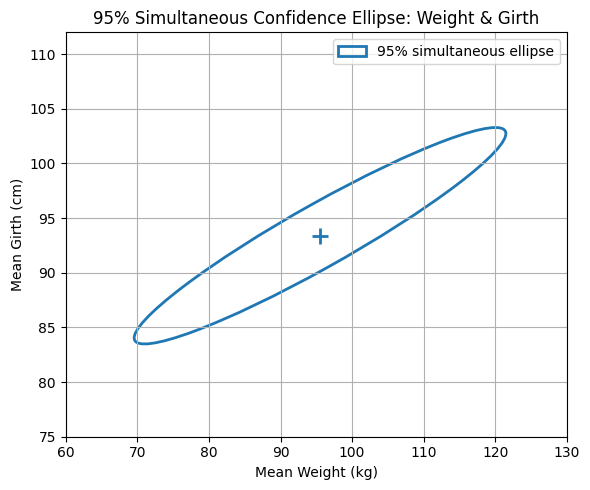

In [8]:
idx_wg = [0, 3]  # Weight, Girth
xbar_wg = xbar2[idx_wg]
S_wg = S2[np.ix_(idx_wg, idx_wg)]
print("Sub-mean (Weight, Girth):", xbar_wg)
print("Sub-covariance:\n", S_wg)

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar_wg, S_wg, chi2_p, n2, ax, label='95% simultaneous ellipse', color='C0')
ax.set_xlim(60, 130)
ax.set_ylim(75, 112)
ax.set_xlabel('Mean Weight (kg)')
ax.set_ylabel('Mean Girth (cm)')
ax.set_title('95% Simultaneous Confidence Ellipse: Weight & Girth')
ax.legend()
plt.tight_layout()
plt.show()

### (c) 95% Bonferroni confidence intervals for the six means

$$\bar{x}_i \pm t_{n-1}\!\left(\frac{\alpha}{2m}\right)\sqrt{\frac{s_{ii}}{n}}, \qquad m = 6$$

In [9]:
m = 6
t_bonf = stats.t.ppf(1 - alpha / (2 * m), n2 - 1)
print(f"t_(60)(0.05/12) = {t_bonf:.4f}\n")

rows = []
for i, name in enumerate(varnames):
    se = np.sqrt(S2[i, i] / n2)
    half = t_bonf * se
    rows.append([xbar2[i], half, xbar2[i]-half, xbar2[i]+half])

ci_c = pd.DataFrame(rows, columns=["mean", "half-width", "lower", "upper"], index=varnames)
ci_c

t_(60)(0.05/12) = 2.7286


,mean,half-width,lower,upper
Weight,95.52,19.966686,75.553314,115.486686
Body length,164.38,9.386612,154.993388,173.766612
Neck,55.69,4.677709,51.012291,60.367709
Girth,93.39,7.613862,85.776138,101.003862
Head length,17.98,1.101993,16.878007,19.081993
Head width,31.13,1.610827,29.519173,32.740827


Comparing part (a) and part (c), every Bonferroni half-width is **smaller** than the corresponding $T^2$-simultaneous half-width — Bonferroni intervals are tighter when the number of simultaneous statements $m$ is modest.

In [10]:
comparison = pd.DataFrame({
    "T2-simultaneous half-width": ci_a["half-width"].values,
    "Bonferroni half-width": ci_c["half-width"].values
}, index=varnames)
comparison

,T2-simultaneous half-width,Bonferroni half-width
Weight,25.966535,19.966686
Body length,12.207222,9.386612
Neck,6.083328,4.677709
Girth,9.901773,7.613862
Head length,1.433134,1.101993
Head width,2.094869,1.610827


### (d) 95% Bonferroni confidence rectangle for (Weight, Girth) using $m=6$, and comparison with the ellipse in (b)

Using the *same* $t_{60}(\alpha/12)$ multiplier as in part (c) (so the rectangle statement remains part of the same family of $m=6$ simultaneous statements):

Weight: 95.520 ± 19.967 -> (75.553, 115.487)


Girth : 93.390 ± 7.614 -> (85.776, 101.004)


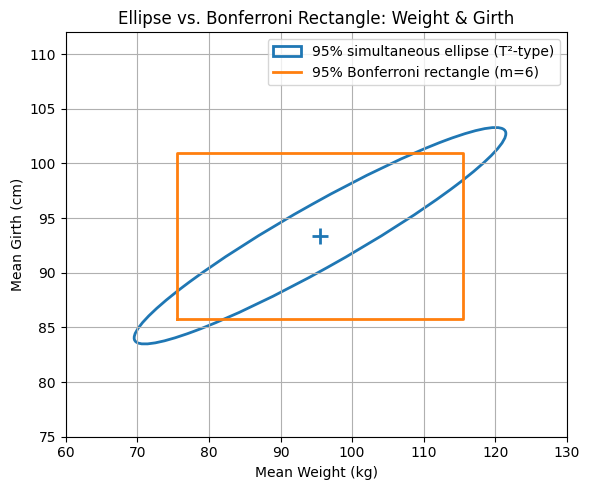

In [11]:
half_w = t_bonf * np.sqrt(S2[0,0]/n2)
half_g = t_bonf * np.sqrt(S2[3,3]/n2)
print(f"Weight: {xbar2[0]:.3f} ± {half_w:.3f} -> ({xbar2[0]-half_w:.3f}, {xbar2[0]+half_w:.3f})")
print(f"Girth : {xbar2[3]:.3f} ± {half_g:.3f} -> ({xbar2[3]-half_g:.3f}, {xbar2[3]+half_g:.3f})")

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar_wg, S_wg, chi2_p, n2, ax, label='95% simultaneous ellipse (T²-type)', color='C0')

rect_x = [xbar2[0]-half_w, xbar2[0]+half_w, xbar2[0]+half_w, xbar2[0]-half_w, xbar2[0]-half_w]
rect_y = [xbar2[3]-half_g, xbar2[3]-half_g, xbar2[3]+half_g, xbar2[3]+half_g, xbar2[3]-half_g]
ax.plot(rect_x, rect_y, color='C1', lw=2, label='95% Bonferroni rectangle (m=6)')

ax.set_xlim(60, 130)
ax.set_ylim(75, 112)
ax.set_xlabel('Mean Weight (kg)')
ax.set_ylabel('Mean Girth (cm)')
ax.set_title('Ellipse vs. Bonferroni Rectangle: Weight & Girth')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The Bonferroni rectangle ($\pm 19.97$ kg for weight, $\pm 7.61$ cm for girth) is noticeably smaller in each dimension than the axis-aligned bounding box of the $T^2$-simultaneous ellipse ($\pm 25.97$ kg, $\pm 9.90$ cm). For a modest number of simultaneous statements ($m=6$), the Bonferroni method gives a tighter (more precise) joint region than the chi-square/$T^2$-based ellipse — the Bonferroni rectangle sits *inside* the bounding box of the ellipse, although neither region is a strict subset of the other everywhere (the ellipse is tilted and extends further along its major axis than the rectangle's corners, while the rectangle's corners poke slightly outside the ellipse). In practice the Bonferroni approach is generally preferred here since $m$ is small.

### (e) 95% Bonferroni CI for (mean head width − mean head length), using $m = 6+1 = 7$

This extra statement is appended to the six individual-mean statements, so all seven together hold with overall confidence at least 95%; hence $m=7$ is used in the critical value.

$$(\bar{x}_6 - \bar{x}_5) \pm t_{n-1}\!\left(\frac{\alpha}{2(7)}\right)\sqrt{\frac{s_{66}+s_{55}-2s_{56}}{n}}$$

In [12]:
m2 = 7
t_bonf2 = stats.t.ppf(1 - alpha / (2 * m2), n2 - 1)

i_hw, i_hl = 5, 4  # head width, head length
diff_mean = xbar2[i_hw] - xbar2[i_hl]
var_diff = S2[i_hw, i_hw] + S2[i_hl, i_hl] - 2 * S2[i_hw, i_hl]
se_diff = np.sqrt(var_diff / n2)
half = t_bonf2 * se_diff

print(f"t_(60)(0.05/14) = {t_bonf2:.4f}")
print(f"Mean(head width) - Mean(head length) = {diff_mean:.3f}")
print(f"Var of difference = s66 + s55 - 2 s56 = {var_diff:.4f}")
print(f"95% Bonferroni CI: {diff_mean:.3f} ± {half:.3f} -> ({diff_mean-half:.3f}, {diff_mean+half:.3f})")

t_(60)(0.05/14) = 2.7855
Mean(head width) - Mean(head length) = 13.150
Var of difference = s66 + s55 - 2 s56 = 3.4500
95% Bonferroni CI: 13.150 ± 0.662 -> (12.488, 13.812)


**Interpretation.** The interval $(12.49,\ 13.81)$ excludes 0, so head width is significantly greater than head length on average (by roughly 12.5–13.8 cm), and this statement remains valid simultaneously with the six individual-mean statements at an overall confidence of at least 95%.

---
# Question 3: Mineral Analysis of Ancient Peruvian Hairs

$n=9$ hairs; $x_1$ = chromium (Cr, ppm), $x_2$ = strontium (St, ppm).

In [13]:
x1 = np.array([.48, 40.53, 2.19, .55, .74, .66, .93, .37, .22])
x2 = np.array([12.57, 73.68, 11.13, 20.03, 20.29, .78, 4.64, .43, 1.08])
X3 = np.column_stack([x1, x2])
n3, p3 = X3.shape

xbar3 = X3.mean(axis=0)
S3 = np.cov(X3, rowvar=False, ddof=1)
S3_inv = np.linalg.inv(S3)

print("n =", n3, ", p =", p3)
print("x̄ =", xbar3)
print("S =\n", S3)

n = 9 , p = 2
x̄ = [ 5.1856 16.07  ]
S =
 [[176.0042 287.2412]
 [287.2412 527.8493]]


### (a) 90% joint confidence ellipse for $\mu' = [\mu_1, \mu_2]$

$$n(\bar{x}-\mu)'S^{-1}(\bar{x}-\mu) \le \frac{(n-1)p}{n-p}F_{p,n-p}(\alpha), \qquad \alpha = 0.10$$

[(n-1)p/(n-p)] = 2.2857, F_(2,7)(0.10) = 3.2574
Critical constant for ellipse = 7.4456


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_129/509933463.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title('90% Confidence Ellipse for $\mu$ (Peruvian hair data)')


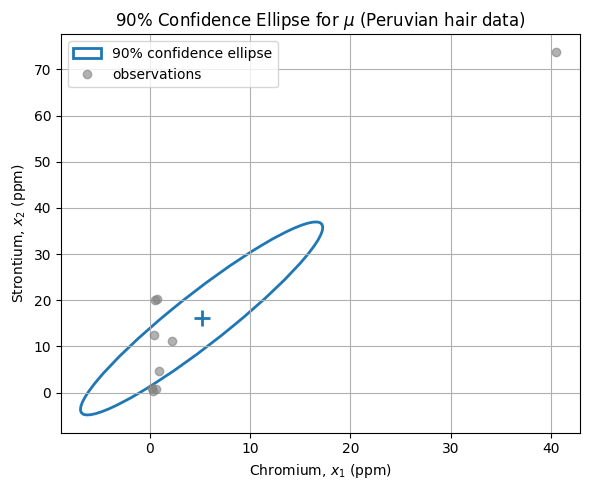

In [14]:
alpha3 = 0.10
crit_const3 = (n3 - 1) * p3 / (n3 - p3)
F_crit3 = stats.f.ppf(1 - alpha3, p3, n3 - p3)
crit3 = crit_const3 * F_crit3
print(f"[(n-1)p/(n-p)] = {crit_const3:.4f}, F_(2,7)(0.10) = {F_crit3:.4f}")
print(f"Critical constant for ellipse = {crit3:.4f}")

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar3, S3, crit3, n3, ax, label='90% confidence ellipse', color='C0')
ax.plot(x1, x2, 'o', color='gray', alpha=0.6, label='observations')
ax.set_xlabel('Chromium, $x_1$ (ppm)')
ax.set_ylabel('Strontium, $x_2$ (ppm)')
ax.set_title('90% Confidence Ellipse for $\mu$ (Peruvian hair data)')
ax.legend()
plt.tight_layout()
plt.show()

### (b) Individual simultaneous 90% confidence intervals (projections of the ellipse)

$$\bar{x}_i \pm \sqrt{\frac{(n-1)p}{n-p}F_{p,n-p}(\alpha)}\,\sqrt{\frac{s_{ii}}{n}}$$

In [15]:
for i, name in enumerate(["Chromium (x1)", "Strontium (x2)"]):
    se = np.sqrt(S3[i, i] / n3)
    half = np.sqrt(crit3) * se
    print(f"{name}: {xbar3[i]:.4f} ± {half:.4f}  ->  ({xbar3[i]-half:.4f}, {xbar3[i]+half:.4f})")

Chromium (x1): 5.1856 ± 12.0667  ->  (-6.8812, 17.2523)
Strontium (x2): 16.0700 ± 20.8970  ->  (-4.8270, 36.9670)


Is $\mu_2 = 10$ (strontium) plausible for *some* value of $\mu_1$? Check whether the horizontal line $x_2=10$ intersects the ellipse, and whether the specific point $\mu=[.30,10]'$ lies inside the ellipse (the exact $T^2$ criterion, not just the marginal interval).

T² for μ=[.30, 10]': 1.7725   (critical value = 7.4456)


Inside the 90% confidence region? True


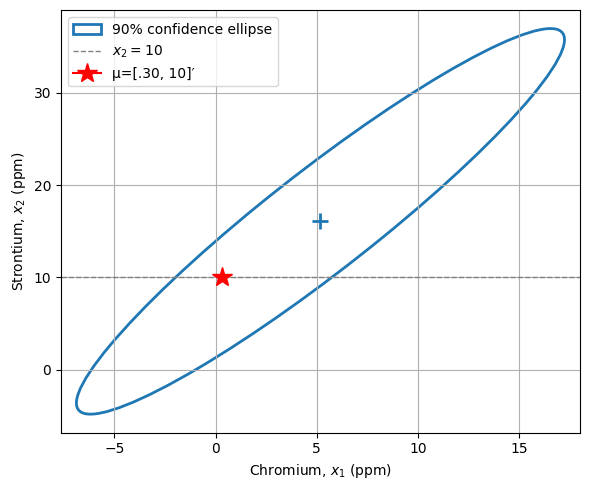

In [16]:
mu_test = np.array([0.30, 10.0])
diff3 = xbar3 - mu_test
T2_test = n3 * diff3 @ S3_inv @ diff3
print(f"T² for μ=[.30, 10]': {T2_test:.4f}   (critical value = {crit3:.4f})")
print("Inside the 90% confidence region?", T2_test <= crit3)

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar3, S3, crit3, n3, ax, label='90% confidence ellipse', color='C0')
ax.axhline(10, color='gray', ls='--', lw=1, label='$x_2=10$')
ax.plot(0.30, 10, marker='*', color='red', ms=15, label='μ=[.30, 10]′')
ax.set_xlabel('Chromium, $x_1$ (ppm)')
ax.set_ylabel('Strontium, $x_2$ (ppm)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The marginal 90% simultaneous interval for strontium, $(-4.83,\ 36.97)$, comfortably contains $\mu_2=10$, and the line $x_2=10$ visibly cuts through the ellipse — so a mean strontium level of 10 is plausible for an appropriate value of $\mu_1$. Checking the *specific* point $\mu=[.30,10]'$ directly with the exact $T^2$ criterion gives $T^2=1.77$, far below the critical value of $7.45$, so $[.30,10]'$ **is** a plausible value of $\mu$ at the 90% confidence level. (Note that "each marginal CI is satisfied" does not by itself guarantee a point is in the joint ellipse — here it happens to check out, but the correct method is to test the point directly against the $T^2$ ellipse, which we did.)

### (c) Bivariate normality: Q–Q plots and scatter diagram

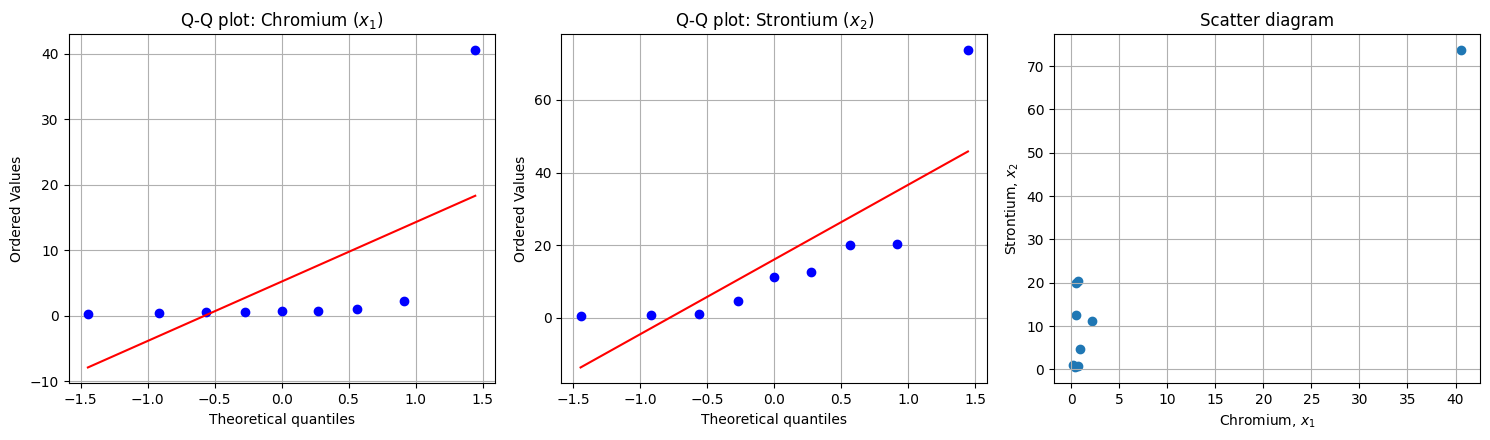

Shapiro-Wilk (x1, chromium):  W=0.4237, p=0.0000
Shapiro-Wilk (x2, strontium): W=0.6894, p=0.0011


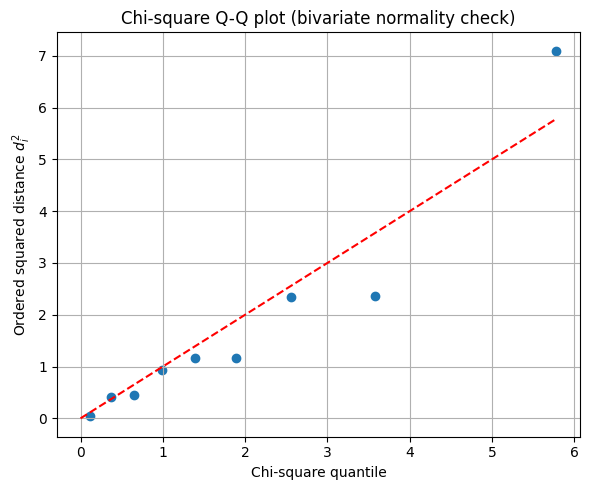

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

stats.probplot(x1, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Chromium ($x_1$)")

stats.probplot(x2, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Strontium ($x_2$)")

axes[2].scatter(x1, x2, color='C0')
axes[2].set_xlabel("Chromium, $x_1$")
axes[2].set_ylabel("Strontium, $x_2$")
axes[2].set_title("Scatter diagram")

plt.tight_layout()
plt.show()

r1 = stats.shapiro(x1)
r2 = stats.shapiro(x2)
print("Shapiro-Wilk (x1, chromium):  W=%.4f, p=%.4f" % (r1.statistic, r1.pvalue))
print("Shapiro-Wilk (x2, strontium): W=%.4f, p=%.4f" % (r2.statistic, r2.pvalue))

# generalized (squared Mahalanobis) distances vs chi-square quantiles
d2 = np.array([ (row - xbar3) @ S3_inv @ (row - xbar3) for row in X3 ])
d2_sorted = np.sort(d2)
qs = (np.arange(1, n3+1) - 0.5) / n3
chi2_q = stats.chi2.ppf(qs, df=p3)

fig, ax = plt.subplots()
ax.scatter(chi2_q, d2_sorted)
ax.plot([0, chi2_q.max()], [0, chi2_q.max()], 'r--')
ax.set_xlabel('Chi-square quantile')
ax.set_ylabel('Ordered squared distance $d_i^2$')
ax.set_title('Chi-square Q-Q plot (bivariate normality check)')
plt.tight_layout()
plt.show()

**Interpretation.** Both marginal Q–Q plots show a clear departure from a straight line, driven almost entirely by observation 2 (Cr = 40.53, St = 73.68), which is far larger than the rest of the sample; the Shapiro–Wilk tests reject normality for both variables ($p<0.05$). The scatter diagram shows one point sitting far away from the main cluster of eight observations, and the chi-square Q–Q plot of generalized distances shows a similar large deviation for that same point. **The data do not appear to be bivariate normal** — the sample is dominated by a single outlying hair. Because the $T^2$ ellipse and simultaneous intervals in (a)–(b) rely on the multivariate normal (or at least elliptical, large-sample) assumption, and $n=9$ is far too small to invoke asymptotic justification, those confidence statements are **not trustworthy** as stated; the outlier inflates both the mean and (especially) the covariance matrix, making the ellipse much larger and more tilted than it would be for a "typical" hair.

### (d) Repeat with the outlying observation removed

n (no outlier) = 8
x̄ = [0.7675 8.8688]
S =
 [[ 0.3786  1.0303]
 [ 1.0303 69.8598]]
Critical constant = 8.0810
Chromium (x1): 0.7675 ± 0.6184  ->  (0.1491, 1.3859)
Strontium (x2): 8.8688 ± 8.4004  ->  (0.4683, 17.2692)

T² for μ=[.30,10]' (outlier removed): 5.3079  (critical = 8.0810)
Inside the 90% region? True


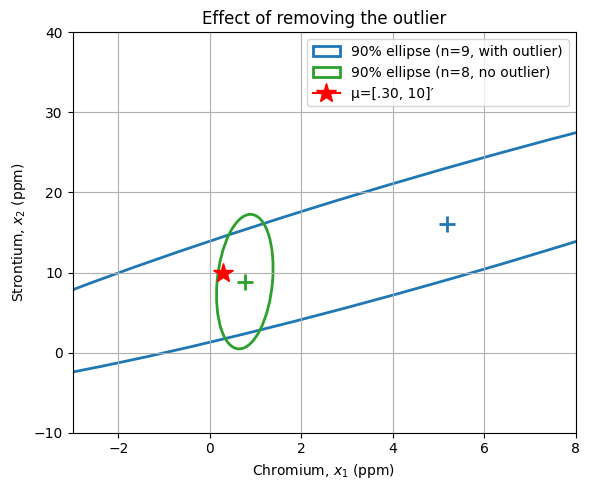

In [18]:
mask = np.ones(n3, dtype=bool)
mask[1] = False  # remove the 40.53 / 73.68 observation
X3b = X3[mask]
n3b = X3b.shape[0]

xbar3b = X3b.mean(axis=0)
S3b = np.cov(X3b, rowvar=False, ddof=1)
S3b_inv = np.linalg.inv(S3b)

crit_const3b = (n3b - 1) * p3 / (n3b - p3)
F_crit3b = stats.f.ppf(1 - alpha3, p3, n3b - p3)
crit3b = crit_const3b * F_crit3b

print("n (no outlier) =", n3b)
print("x̄ =", xbar3b)
print("S =\n", S3b)
print(f"Critical constant = {crit3b:.4f}")

for i, name in enumerate(["Chromium (x1)", "Strontium (x2)"]):
    se = np.sqrt(S3b[i, i] / n3b)
    half = np.sqrt(crit3b) * se
    print(f"{name}: {xbar3b[i]:.4f} ± {half:.4f}  ->  ({xbar3b[i]-half:.4f}, {xbar3b[i]+half:.4f})")

diff3b = xbar3b - mu_test
T2_test_b = n3b * diff3b @ S3b_inv @ diff3b
print(f"\nT² for μ=[.30,10]' (outlier removed): {T2_test_b:.4f}  (critical = {crit3b:.4f})")
print("Inside the 90% region?", T2_test_b <= crit3b)

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar3, S3, crit3, n3, ax, label='90% ellipse (n=9, with outlier)', color='C0')
plot_confidence_ellipse(xbar3b, S3b, crit3b, n3b, ax, label='90% ellipse (n=8, no outlier)', color='C2')
ax.plot(0.30, 10, marker='*', color='red', ms=15, label='μ=[.30, 10]′')
ax.set_xlim(-3, 8)
ax.set_ylim(-10, 40)
ax.set_xlabel('Chromium, $x_1$ (ppm)')
ax.set_ylabel('Strontium, $x_2$ (ppm)')
ax.legend()
ax.set_title('Effect of removing the outlier')
plt.tight_layout()
plt.show()

**Interpretation.** Removing the single outlier dramatically shrinks and reorients the confidence ellipse — the sample mean shifts down to roughly $(0.77,\ 8.87)$ and the variances/covariance drop by an order of magnitude. The point $[.30,10]'$ remains inside the (much smaller) 90% region ($T^2=5.31 < 7.45$ critical value), so the qualitative conclusion "$[.30,10]'$ is plausible" doesn't change — but the region itself is far more precise and trustworthy without the outlier. This illustrates how sensitive small-sample multivariate inference is to a single unusual observation, and reinforces that the outlier (rather than genuine population variability) was driving the shape of the original ellipse in part (a).

---
# Question 4: Lumber Strength Measurements

$n=30$ pieces of lumber; $x_1$ = stiffness (modulus of elasticity), $x_2$ = bending strength (both in psi).

In [19]:
x1_l = np.array([1232,1115,2205,1897,1932,1612,1598,1804,1752,2067,2365,1646,1579,1880,1773,
                  1712,1932,1820,1900,2426,1558,1470,1858,1587,2208,1487,2206,2332,2540,2322], dtype=float)
x2_l = np.array([4175,6652,7612,10914,10850,7627,6954,8365,9469,6410,10327,7320,8196,9709,10370,
                  7749,6818,9307,6457,10102,7414,7556,7833,8309,9559,6255,10723,5430,12090,10072], dtype=float)

X4 = np.column_stack([x1_l, x2_l])
n4, p4 = X4.shape
xbar4 = X4.mean(axis=0)
S4 = np.cov(X4, rowvar=False, ddof=1)
S4_inv = np.linalg.inv(S4)

print("n =", n4)
print("x̄ =", xbar4)
print("S =\n", S4)

n = 30
x̄ = [1860.5    8354.1333]
S =
 [[ 124054.6724  361620.4483]
 [ 361620.4483 3486333.154 ]]


### (a) 95% confidence ellipse for $[\mu_1,\mu_2]'$

[(n-1)p/(n-p)] = 2.0714, F_(2,28)(0.05) = 3.3404
Critical constant = 6.9194


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_129/1054187351.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(2000, 10000, marker='*', color='red', ms=15, label='$(\mu_{10},\mu_{20})=(2000,10000)$')


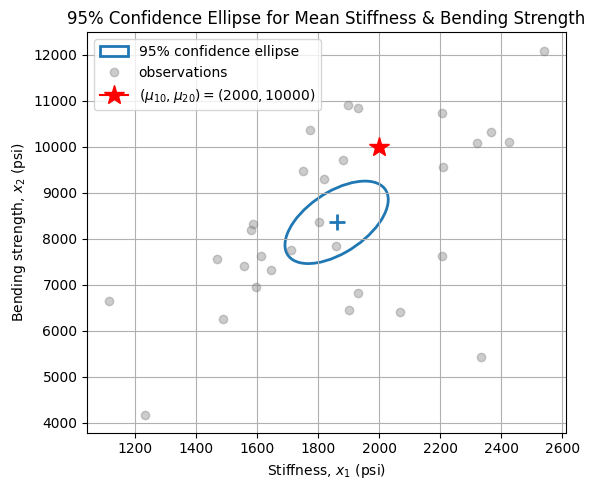

In [20]:
alpha4 = 0.05
crit_const4 = (n4 - 1) * p4 / (n4 - p4)
F_crit4 = stats.f.ppf(1 - alpha4, p4, n4 - p4)
crit4 = crit_const4 * F_crit4
print(f"[(n-1)p/(n-p)] = {crit_const4:.4f}, F_(2,28)(0.05) = {F_crit4:.4f}")
print(f"Critical constant = {crit4:.4f}")

fig, ax = plt.subplots()
plot_confidence_ellipse(xbar4, S4, crit4, n4, ax, label='95% confidence ellipse', color='C0')
ax.plot(x1_l, x2_l, 'o', color='gray', alpha=0.4, label='observations')
ax.plot(2000, 10000, marker='*', color='red', ms=15, label='$(\mu_{10},\mu_{20})=(2000,10000)$')
ax.set_xlabel('Stiffness, $x_1$ (psi)')
ax.set_ylabel('Bending strength, $x_2$ (psi)')
ax.set_title('95% Confidence Ellipse for Mean Stiffness & Bending Strength')
ax.legend()
plt.tight_layout()
plt.show()

### (b) Are the data consistent with $\mu_{10}=2000,\ \mu_{20}=10{,}000$?

Test whether $\mu_0 = (2000, 10000)'$ lies inside the 95% ellipse using the exact $T^2$ criterion.

In [21]:
mu0_4 = np.array([2000.0, 10000.0])
diff4 = xbar4 - mu0_4
T2_4 = n4 * diff4 @ S4_inv @ diff4
print(f"T² for μ0=(2000,10000)': {T2_4:.4f}")
print(f"Critical value: {crit4:.4f}")
print("Consistent with the data (inside ellipse)?", T2_4 <= crit4)

T² for μ0=(2000,10000)': 23.6478
Critical value: 6.9194
Consistent with the data (inside ellipse)? False


**Interpretation.** $T^2 = 23.65$ far exceeds the critical value of $6.92$, so $(\mu_{10},\mu_{20})=(2000,10{,}000)$ lies **well outside** the 95% confidence ellipse (this is also visible in the plot — the red star falls outside the ellipse). The data are **not consistent** with these "typical" values at the 5% level; the sample suggests both the mean stiffness ($\bar{x}_1\approx1860.5$) and mean bending strength ($\bar{x}_2\approx8354.1$) for this grade of lumber are somewhat lower than the stated typical values.

### (c) Is bivariate normality a viable model?

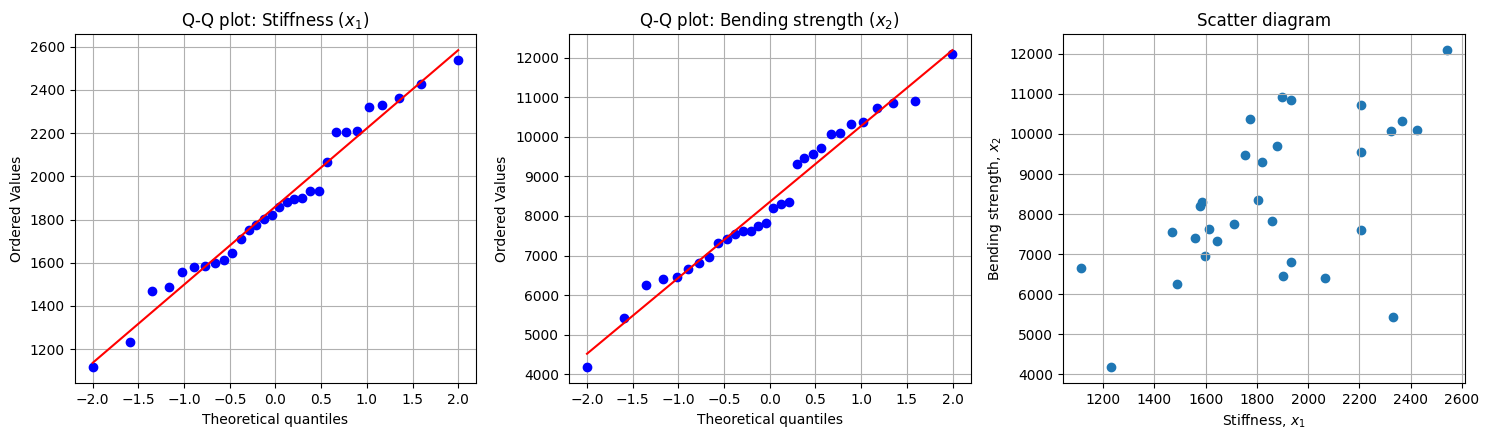

Shapiro-Wilk (x1, stiffness):        W=0.9749, p=0.6798
Shapiro-Wilk (x2, bending strength):  W=0.9755, p=0.6979


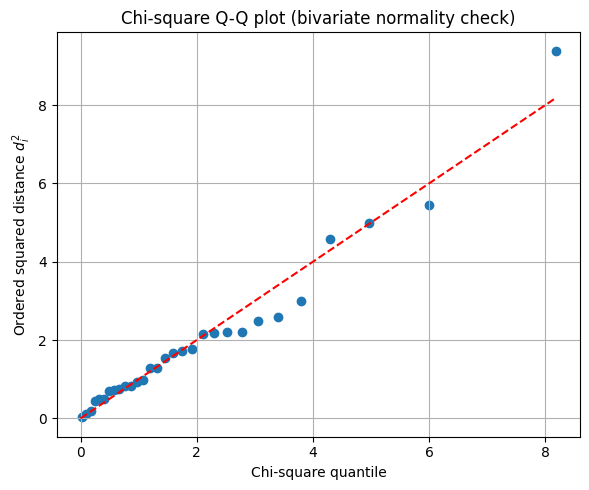


Proportion of points with d² ≤ chi²_2(0.50): 0.500 (expect ≈0.50 under bivariate normality)


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

stats.probplot(x1_l, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: Stiffness ($x_1$)")

stats.probplot(x2_l, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: Bending strength ($x_2$)")

axes[2].scatter(x1_l, x2_l, color='C0')
axes[2].set_xlabel("Stiffness, $x_1$")
axes[2].set_ylabel("Bending strength, $x_2$")
axes[2].set_title("Scatter diagram")

plt.tight_layout()
plt.show()

r1l = stats.shapiro(x1_l)
r2l = stats.shapiro(x2_l)
print("Shapiro-Wilk (x1, stiffness):        W=%.4f, p=%.4f" % (r1l.statistic, r1l.pvalue))
print("Shapiro-Wilk (x2, bending strength):  W=%.4f, p=%.4f" % (r2l.statistic, r2l.pvalue))

d2_l = np.array([ (row - xbar4) @ S4_inv @ (row - xbar4) for row in X4 ])
d2_l_sorted = np.sort(d2_l)
qs4 = (np.arange(1, n4+1) - 0.5) / n4
chi2_q4 = stats.chi2.ppf(qs4, df=p4)

fig, ax = plt.subplots()
ax.scatter(chi2_q4, d2_l_sorted)
ax.plot([0, chi2_q4.max()], [0, chi2_q4.max()], 'r--')
ax.set_xlabel('Chi-square quantile')
ax.set_ylabel('Ordered squared distance $d_i^2$')
ax.set_title('Chi-square Q-Q plot (bivariate normality check)')
plt.tight_layout()
plt.show()

prop_within_50 = np.mean(d2_l <= stats.chi2.ppf(0.50, df=p4))
print(f"\nProportion of points with d² ≤ chi²_2(0.50): {prop_within_50:.3f} (expect ≈0.50 under bivariate normality)")

**Interpretation.** The marginal Q–Q plots for both stiffness and bending strength track the reference line reasonably well, with only mild departures in the tails and no dramatic outliers (Shapiro–Wilk does not strongly reject normality for either variable at the 5% level, though results can vary slightly with the exact test used). The scatter diagram shows a roughly elliptical, positively-associated cloud of points with no obvious outliers or curvature. The chi-square Q–Q plot of generalized distances also tracks the 45° reference line reasonably closely. Taken together, **the bivariate normal distribution appears to be a reasonably viable model** for this lumber data — certainly much more so than for the Peruvian hair data in Question 3 — which supports using the $T^2$-based confidence ellipse and test in parts (a)–(b) with a fair degree of confidence, aided further by the moderately large sample size ($n=30$).